In [30]:
from pyPLNmodels.utils import build_block_Sigma, C_from_Sigma, sample_PLN, MSE, refined_MSE, MSE, log_stirling
import torch
#from fastPLNmodels.models import IMPS_PLN, log_likelihood, fastPLN, fastPLNPCA, PLNmodel
from pyPLNmodels.models import IMPS_PLN, ELBO, fastPLN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time 

In [31]:
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else : 
    device = torch.device('cpu')
#device = torch.device('cpu') # think I can't use RTX A5000 right now, will check this later. 
torch.cuda.is_available()

False

In [32]:
%load_ext autoreload

%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
d = 2
n = 250;  p = 30
q = 5


In [42]:
#torch.manual_seed(0)
Sigma_sampling = 1*torch.from_numpy(build_block_Sigma(p,q))/4 #+ 0.5*torch.eye(p)
true_C = C_from_Sigma(Sigma_sampling, q).to(device)
true_Sigma_sampling = true_C@(true_C.T)
true_beta =torch.randn((d, p), device = device )*0.75
covariates = torch.randn((n,d), device = device)/1
O =  1+torch.zeros((n,p), device = device)
Y, Z,_  = sample_PLN(true_C,true_beta, O, covariates)

In [51]:
pd.DataFrame(true_Sigma_sampling.numpy()).to_csv('true_5_Sigma.csv', index = None)
pd.DataFrame(true_beta.numpy()).to_csv('true_beta.csv', index = None)
pd.DataFrame(Y.numpy()).to_csv('Y.csv', index = None)
pd.DataFrame(O.numpy()).to_csv('O.csv', index = None)
pd.DataFrame(covariates.numpy()).to_csv('covariates.csv', index = None)


In [57]:
test = torch.randn(30,30)
np.linalg.eigvalsh(test.numpy())

array([-9.43951684, -9.10774028, -7.92328435, -7.67313397, -7.01537427,
       -6.81132961, -5.23973793, -4.89069058, -3.89415507, -3.21268484,
       -2.7225535 , -2.21141416, -1.29294192, -0.9471162 , -0.58507795,
       -0.18606767,  1.18892522,  1.59995201,  1.9878193 ,  2.22126013,
        3.11855698,  3.51806565,  3.80205935,  4.57711963,  5.18183316,
        5.85320786,  6.18902463,  6.80953239,  9.72462113, 10.56959601])

<AxesSubplot:>

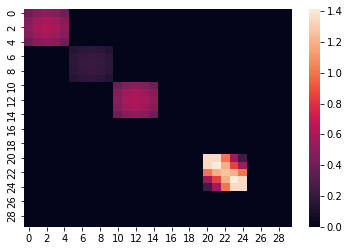

In [47]:
sns.heatmap((true_C@(true_C.T)).cpu())

In [8]:
mypln = IMPS_PLN(q=10)
mypln.fit(Y,O,covariates)

Intialization ...
C grad None
Initalization done


  0%|          | 1/500 [00:01<10:21,  1.24s/it]

log like random -78.22864590400133


  0%|          | 2/500 [00:02<08:07,  1.02it/s]

log like random -76.67513172857431


...

log like random -70.31878613867897


 25%|██▌       | 127/500 [01:25<03:24,  1.82it/s]

log like random -70.34052534233533


 25%|██▌       | 127/500 [01:25<04:11,  1.48it/s]

log like random -70.26403046473312
Algorithm stopped after  127  iterations


Device  cpu
Best likelihood:  -68.83256862661136
len log_list 75
len runtime 75


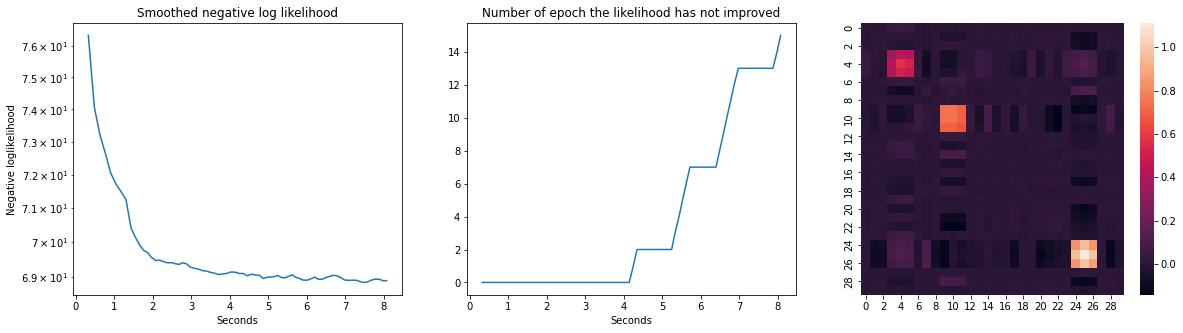

<Figure size 432x288 with 0 Axes>

In [14]:
print(mypln)

### Test with the test data from the package. 

In [19]:
import pandas as pd 

Y = pd.read_csv('example_data/Y_test')
O = pd.read_csv('example_data/O_test')
covariates = pd.read_csv('example_data/cov_test')
true_Sigma = torch.from_numpy(pd.read_csv('example_data/true_Sigma_test').values)
true_beta = torch.from_numpy(pd.read_csv('example_data/true_beta_test').values)

In [29]:
mypln = IMPS_PLN(q=5)
mypln.fit(Y,pd.DataFrame(np.exp(O)),covariates, batch_size = Y.shape[0], verbose = True, optimizer = torch.optim.Adagrad, good_init = True) 

Intialization ...
C grad None
Initalization done


  0%|          | 1/500 [00:00<04:32,  1.83it/s]

log like random -110.26053427160083
Average log likelihood :  -110.26053427160083


  0%|          | 2/500 [00:01<04:08,  2.01it/s]

log like random -108.66127040966387
Average log likelihood :  -109.46090234063234


...

log like random -103.06675316507419
Average log likelihood :  -103.05586197334239
Criterion updated :  13 / 15


 23%|██▎       | 115/500 [00:43<02:37,  2.44it/s]

log like random -103.0276505217208
Average log likelihood :  -103.05133236141955
Criterion updated :  14 / 15


 23%|██▎       | 115/500 [00:44<02:27,  2.61it/s]

log like random -103.03033236642844
Average log likelihood :  -103.05178384802642
Criterion updated :  15 / 15
Algorithm stopped after  115  iterations


In [24]:
pln = IMPS_PLN(q=5)
pln.fit(Y,pd.DataFrame(np.exp(O)), covariates)

Intialization ...
C grad None
Initalization done


  0%|          | 1/500 [00:01<09:06,  1.10s/it]

log like random -114.30297395170246


  0%|          | 2/500 [00:02<08:31,  1.03s/it]

log like random -106.58134298890191


...

log like random -103.00572473618017


 26%|██▌       | 130/500 [01:26<03:48,  1.62it/s]

log like random -103.07171504142548


 26%|██▌       | 130/500 [01:27<04:08,  1.49it/s]

log like random -103.00799437359828
Algorithm stopped after  130  iterations


Best likelihood:  -103.03583989588856


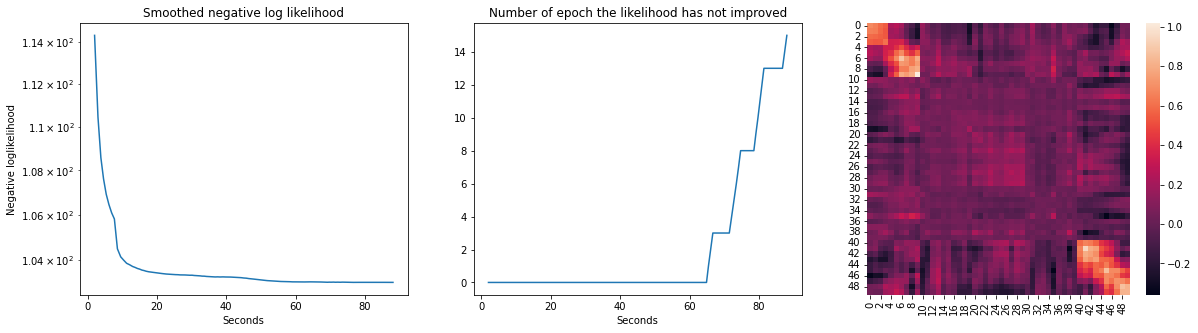

<Figure size 432x288 with 0 Axes>

In [25]:
print(pln)

### Test with oaks data 

In [74]:
from pandas import read_csv
import pandas as pd
import numpy as np
from pyPLNmodels.models import fastPLNPCA, IMPS_PLN, fastPLN

Device  cpu


In [75]:
Y = read_csv('oaks_counts.csv', sep=',')
O = np.log(read_csv('oaks_offsets.csv', sep=','))
cov = pd.DataFrame(np.ones(116).reshape(-1,1))

In [22]:
mypln = fastPLNPCA(10)
mypln.fit(Y,O,cov, verbose = True, N_iter_max = 5000, tol = 0.0001)

Device  cpu


NameError: name 'fastPLNPCA' is not defined

Best ELBO:  -460.33761967664003


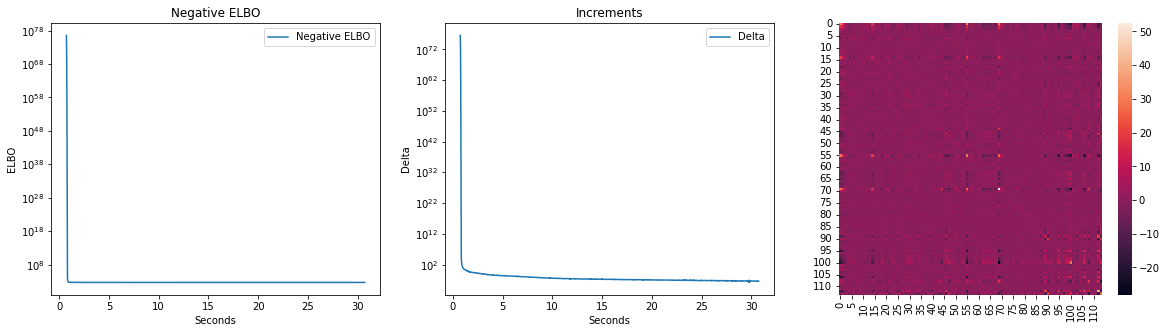

<Figure size 432x288 with 0 Axes>

In [73]:
print(mypln)

Best ELBO:  -723.3288159758526


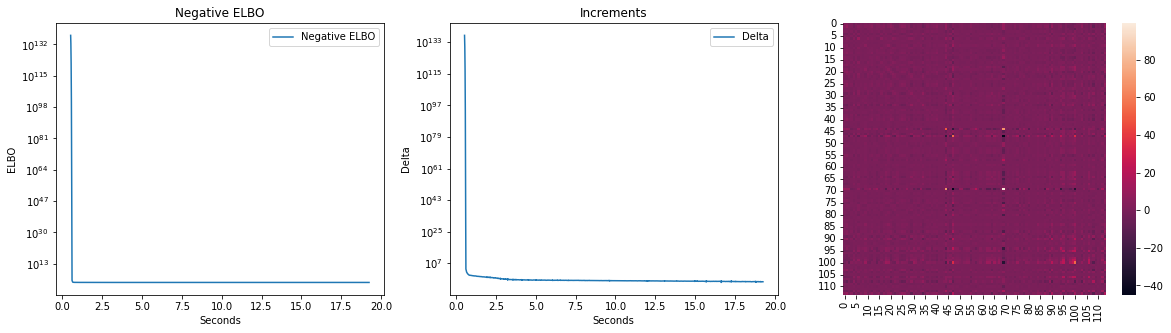

<Figure size 432x288 with 0 Axes>

In [69]:
print(mypln)

In [81]:
imps = IMPS_PLN(5)
imps.fit(Y,O,cov, optimizer = torch.optim.Rprop, nb_plateau = 1000, batch_size = 116)

Device  cpu
Intialization ...
C grad None
Initalization done


  0%|          | 0/500 [00:00<?, ?it/s]

size W torch.Size([200, 116, 5])
weights shape torch.Size([200, 116])


  0%|          | 1/500 [00:00<02:41,  3.09it/s]

size W torch.Size([200, 116, 5])
weights shape torch.Size([200, 116])


...

100%|█████████▉| 498/500 [02:21<00:00,  3.62it/s]

size W torch.Size([200, 116, 5])
weights shape torch.Size([200, 116])


100%|█████████▉| 499/500 [02:22<00:00,  3.85it/s]

size W torch.Size([200, 116, 5])
weights shape torch.Size([200, 116])


100%|██████████| 500/500 [02:22<00:00,  3.51it/s]


<AxesSubplot:>

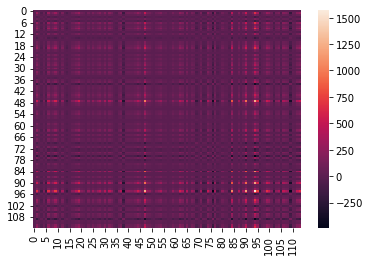

In [63]:
sns.heatmap(imps.get_Sigma())

In [29]:
O

,b_OTU_1045,b_OTU_109,b_OTU_1093,b_OTU_11,b_OTU_112,b_OTU_1191,b_OTU_1200,b_OTU_123,b_OTU_13,b_OTU_1431,...,f_OTU_662,f_OTU_672,f_OTU_1011,f_OTU_1085,f_OTU_1090,f_OTU_1141,f_OTU_1278,f_OTU_1567,f_OTU_1656,E_alphitoides
0,8315,8315,8315,8315,8315,8315,8315,8315,8315,8315,...,2488,2488,2488,2488,2488,2488,2488,2488,2488,2488
1,662,662,662,662,662,662,662,662,662,662,...,2054,2054,2054,2054,2054,2054,2054,2054,2054,2054
2,480,480,480,480,480,480,480,480,480,480,...,2122,2122,2122,2122,2122,2122,2122,2122,2122,2122
3,674,674,674,674,674,674,674,674,674,674,...,2625,2625,2625,2625,2625,2625,2625,2625,2625,2625
4,643,643,643,643,643,643,643,643,643,643,...,2469,2469,2469,2469,2469,2469,2469,2469,2469,2469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,190,190,190,190,190,190,190,190,190,190,...,2053,2053,2053,2053,2053,2053,2053,2053,2053,2053
112,1975,1975,1975,1975,1975,1975,1975,1975,1975,1975,...,1456,1456,1456,1456,1456,1456,1456,1456,1456,1456
113,1188,1188,1188,1188,1188,1188,1188,1188,1188,1188,...,1510,1510,1510,1510,1510,1510,1510,1510,1510,1510
114,322,322,322,322,322,322,322,322,322,322,...,1921,1921,1921,1921,1921,1921,1921,1921,1921,1921


In [1]:
import torch
x = torch.randn(10,2)
x.grad = torch.randn(10,2)

In [2]:
x.grad

tensor([[ 1.8056, -1.7710],
        [ 0.2039, -0.6443],
        [-1.5273, -2.0573],
        [ 1.3604, -2.0502],
        [ 1.5869, -0.1192],
        [-0.1781, -0.1335],
        [-0.2441, -0.9887],
        [ 1.1216,  0.4265],
        [-0.1369, -0.5592],
        [-0.0288,  1.2899]])

In [101]:
Y

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,5.0,2.0,1.0,7.0,0.0,6.0,8.0,11.0,0.0,0.0,...,5.0,6.0,7.0,3.0,0.0,1.0,2.0,1.0,0.0,3.0
1,2.0,14.0,1.0,15.0,0.0,39.0,20.0,13.0,7.0,14.0,...,1.0,1.0,1.0,0.0,0.0,5.0,6.0,3.0,0.0,0.0
2,3.0,20.0,1.0,1.0,2.0,1.0,0.0,14.0,11.0,3.0,...,3.0,3.0,4.0,0.0,0.0,8.0,3.0,1.0,3.0,2.0
3,1.0,4.0,1.0,5.0,0.0,3.0,2.0,2.0,1.0,7.0,...,1.0,2.0,8.0,11.0,3.0,8.0,11.0,8.0,13.0,9.0
4,7.0,0.0,3.0,2.0,3.0,1.0,1.0,0.0,1.0,1.0,...,0.0,1.0,0.0,2.0,5.0,2.0,2.0,10.0,5.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.0,8.0,4.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,...,5.0,1.0,0.0,1.0,4.0,0.0,0.0,3.0,3.0,2.0
196,3.0,5.0,2.0,2.0,4.0,0.0,2.0,2.0,0.0,5.0,...,1.0,2.0,0.0,0.0,0.0,0.0,0.0,4.0,7.0,2.0
197,1.0,0.0,1.0,0.0,5.0,3.0,0.0,3.0,10.0,12.0,...,6.0,2.0,2.0,1.0,1.0,0.0,18.0,7.0,5.0,0.0
198,0.0,0.0,8.0,1.0,11.0,8.0,5.0,1.0,5.0,3.0,...,0.0,0.0,3.0,8.0,1.0,0.0,0.0,1.0,0.0,0.0


In [105]:
M = torch.zeros((Y.shape[0],Y.shape[1]))
S = torch.ones((Y.shape[0],Y.shape[1])) 

In [132]:
ELBO(torch.tensor(Y.values),torch.tensor(O.values),torch.tensor(cov.values), M,S,torch.eye(Y.shape[1]), true_beta)

Device  cpu
first tensor(-0.)
sec tensor(2706.9264)
third tensor(-6663.0882)
fourth tensor(-107695.8232)
last tensor(-102695.8232)


tensor(-102695.8232)

In [131]:
torch.sum(log_stirling(torch.tensor(Y.values)))

tensor(101032.7350)

In [125]:
torch.tensor(true_beta.values)

RuntimeError: Could not infer dtype of builtin_function_or_method

In [126]:
true_beta

tensor([[ 0.6449, -0.0671, -0.8059,  0.2873, -0.4520,  0.7971,  0.0388,  0.0770,
          0.3585,  0.6456, -0.0934,  0.0348, -0.9489, -1.3245, -0.8204, -0.8306,
         -1.4865, -0.7314, -0.2895,  1.3384, -0.5768, -0.4615,  0.3915, -1.2587,
          0.8124, -0.0540, -0.8601, -0.5979,  0.6417,  0.0139, -0.0526, -1.2370,
         -0.0040,  0.0619,  0.1080, -1.2573,  1.2136, -0.1891,  2.4108, -0.0814,
          0.0861, -0.3159,  0.5699, -0.6802, -0.1005,  0.4738,  0.6733,  0.2792,
         -1.0044, -0.1666],
        [-0.1825,  0.6562, -0.0871,  0.3745, -0.8185, -0.8110,  0.1466,  0.0463,
         -0.6946, -0.6524, -0.5222, -0.7442,  0.4454, -0.3314, -0.3215,  0.2647,
         -0.1204,  0.0089, -0.1354,  0.0221, -0.7168, -1.3012,  0.3256, -0.3707,
         -0.4588, -0.8179, -0.3519,  0.2703, -0.1902,  0.3857,  0.2473, -0.2273,
         -0.5395,  0.6682, -0.7067,  0.1294,  0.3153, -0.6596, -0.0814, -0.5195,
          0.5576,  0.6685,  0.1128,  0.5035, -0.8434,  1.4620,  0.3609, -0.4854,


In [122]:
torch.tensor(Y.values)

tensor([[ 5.,  2.,  1.,  ...,  1.,  0.,  3.],
        [ 2., 14.,  1.,  ...,  3.,  0.,  0.],
        [ 3., 20.,  1.,  ...,  1.,  3.,  2.],
        ...,
        [ 1.,  0.,  1.,  ...,  7.,  5.,  0.],
        [ 0.,  0.,  8.,  ...,  1.,  0.,  0.],
        [ 1.,  0.,  4.,  ...,  2.,  4.,  0.]])